# K Mean Clustering From Scratch

In [1]:
import matplotlib.pyplot as plt
from numpy.random import uniform
import numpy as np
import pandas as pd

In [2]:
# First, we will create a helper function to calculate the Euclidean distance between two points.
def euclidean(point, centroid):
  return np.sqrt(np.sum((point - centroid) ** 2))

In [3]:
def showplot(X_2d, centroids_2d):
  plt.figure(figsize=(9, 3.5))
  plt.plot(X_2d[:,0], X_2d[:,1], "k*", label="Unlabel instance")
  plt.plot([x for x, _ in centroids_2d],[y for _, y in centroids_2d], '+', markersize=10,)
  plt.xlabel("Component 1", fontsize=10)
  plt.ylabel("Component 2", fontsize=10)
  plt.legend(fontsize=10)
  plt.show()

In [4]:
# Initialize centroids by uniformly distributing them within the data range.
def init_centroids(X, n_clusters, random_state=42):
  np.random.seed(random_state)
  minpoint, maxpoint = np.min(X, axis=0), np.max(X, axis=0)
  centroids = np.array([uniform(low=minpoint, high=maxpoint) for _ in range(n_clusters)])
  return centroids

In [5]:
def showplotwithclass_2d(sorted_x_2d, centroids_2d, title="K-Means Clusters"):
    """Plot clusters using 2D projected data (for visualization only)."""
    plt.figure(figsize=(9, 3.5))
    colors = plt.cm.tab20.colors

    for i, cluster_points in enumerate(sorted_x_2d):
        if len(cluster_points) == 0:
            continue
        cluster_points = np.array(cluster_points)
        plt.plot(cluster_points[:, 0], cluster_points[:, 1],
                 marker='o', linestyle='', color=colors[i % len(colors)],
                 label=f"Cluster {i}")

    centroids_arr = np.array(centroids_2d)
    plt.plot(centroids_arr[:, 0], centroids_arr[:, 1],
             'k+', markersize=15, markeredgewidth=3, label="Centroids")

    plt.xlabel("Component 1", fontsize=10)
    plt.ylabel("Component 2", fontsize=10)
    plt.title(title, fontsize=12)
    plt.legend(fontsize=10)
    plt.show()

In [6]:
def calculateClass(X, centroids, n_clusters):
  """Assign each point to the nearest centroid."""
  sorted_x = [[] for _ in range(n_clusters)]
  labels = np.zeros(len(X), dtype=int)
  for idx, x in enumerate(X):
    dists = [euclidean(x, centroid) for centroid in centroids]
    centroid_idx = np.argmin(dists)
    sorted_x[centroid_idx].append(x)
    labels[idx] = centroid_idx

  sorted_x = [np.array(cluster) if len(cluster) > 0 else np.empty((0, X.shape[1])) for cluster in sorted_x]
  return sorted_x, labels

In [7]:
# Reassign centroids as the mean of the points belonging to them.
def adjustCentroid(sorted_x, centroids):
  prev_centroids = centroids
  new_centroids = []
  for i, cluster in enumerate(sorted_x):
    if len(cluster) > 0:
      new_centroids.append(np.mean(cluster, axis=0))
    else:
      new_centroids.append(prev_centroids[i])  # Keep previous if cluster is empty
  return np.array(new_centroids)

In [8]:
# Training loop: assign clusters -> update centroids -> repeat until convergence
def train(X, n_clusters, max_iters=300, random_state=42):
  centroids = init_centroids(X, n_clusters, random_state)
  labels = None
  for iteration in range(max_iters):
    sorted_x, labels = calculateClass(X, centroids, n_clusters)
    new_centroids = adjustCentroid(sorted_x, centroids)
    if np.allclose(centroids, new_centroids):
      print(f"Converged at iteration {iteration + 1}")
      break
    centroids = new_centroids
  else:
    print(f"Reached max iterations ({max_iters})")

  # Compute inertia (WCSS)
  inertia = sum(euclidean(X[i], centroids[labels[i]])**2 for i in range(len(X)))
  return centroids, labels, sorted_x, inertia

# Attrition Prediction using K-Means from Scratch

In [9]:
# Load the SMOTE-balanced attrition dataset
df = pd.read_csv('../data/processed_data_attrition.csv')

# Separate features and Attrition label
attrition_raw = df['Attrition'].values
attrition_binary = (attrition_raw == attrition_raw.max()).astype(int)  # 1 = Yes, 0 = No
X = df.drop(columns=['Attrition']).values
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"Dataset shape: {X.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"\nAttrition distribution (for reference — NOT used in clustering):")
print(f"  No Attrition (0): {np.sum(attrition_binary == 0)}")
print(f"  Attrition    (1): {np.sum(attrition_binary == 1)}")

Dataset shape: (2464, 36)
Features (36): ['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'PerformanceIndex', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyAchievement', 'NumCompaniesWorked', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'RemoteWork', 'MonthlyIncome', 'WelfareBenefits', 'InHouseFacility', 'ExternalFacility', 'ExtendedLeave', 'FlexibleWork', 'StressSelfReported', 'StressRating']

Attrition distribution (for reference — NOT used in clustering):
  No Attrition (0): 1232
  Attrition    (1): 1232


Elbow Method — Testing K=2 to K=10:

Converged at iteration 13
  K=2: Inertia (WCSS) = 72897.59
Converged at iteration 23
  K=3: Inertia (WCSS) = 68495.62
Converged at iteration 33
  K=4: Inertia (WCSS) = 66185.06
Converged at iteration 17
  K=5: Inertia (WCSS) = 64817.12
Converged at iteration 26
  K=6: Inertia (WCSS) = 63081.70
Converged at iteration 31
  K=7: Inertia (WCSS) = 61862.36
Converged at iteration 61
  K=8: Inertia (WCSS) = 61064.26
Converged at iteration 64
  K=9: Inertia (WCSS) = 59971.10
Converged at iteration 27
  K=10: Inertia (WCSS) = 59375.11


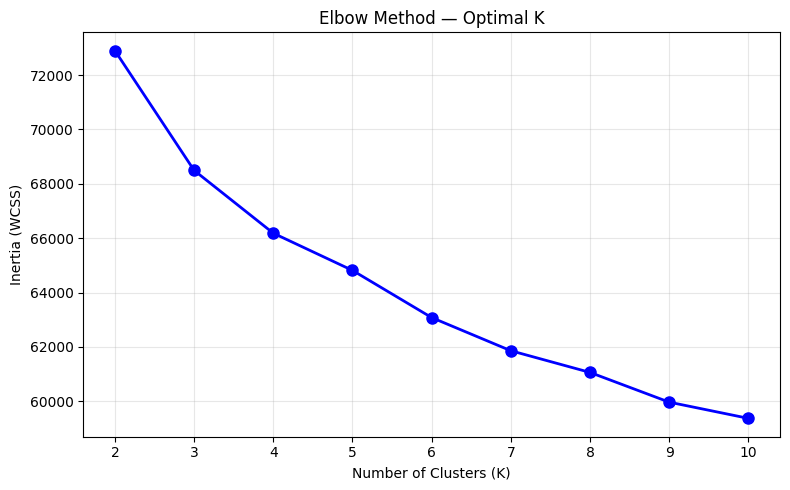

In [10]:
# Elbow Method: find optimal K
print("Elbow Method — Testing K=2 to K=10:\n")
inertias = []
K_range = range(2, 11)

for k in K_range:
    _, _, _, inertia = train(X, n_clusters=k, random_state=42)
    inertias.append(inertia)
    print(f"  K={k}: Inertia (WCSS) = {inertia:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Run K-Means with K=2 (Attrition: Yes / No)
centroids, labels, sorted_x, inertia = train(X, n_clusters=2, random_state=42)

print(f"\nK-Means Clustering with K=2")
print(f"Inertia (WCSS): {inertia:.2f}")
print(f"\nCluster distribution:")
for k in range(2):
    count = np.sum(labels == k)
    print(f"  Cluster {k}: {count} samples ({count/len(labels)*100:.1f}%)")

Converged at iteration 13

K-Means Clustering with K=2
Inertia (WCSS): 72897.59

Cluster distribution:
  Cluster 0: 1433 samples (58.2%)
  Cluster 1: 1031 samples (41.8%)


In [12]:
# Evaluate: map clusters to attrition labels
def map_clusters_to_labels(cluster_labels, true_labels):
    """Try both mappings and pick the one with higher accuracy."""
    acc_1 = np.mean(cluster_labels == true_labels)
    flipped = 1 - cluster_labels
    acc_2 = np.mean(flipped == true_labels)
    if acc_2 > acc_1:
        return flipped, acc_2
    return cluster_labels, acc_1

predicted, accuracy = map_clusters_to_labels(labels, attrition_binary)

# Confusion Matrix & Metrics
tp = np.sum((predicted == 1) & (attrition_binary == 1))
tn = np.sum((predicted == 0) & (attrition_binary == 0))
fp = np.sum((predicted == 1) & (attrition_binary == 0))
fn = np.sum((predicted == 0) & (attrition_binary == 1))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 50)
print("  K-Means (K=2) — Attrition Evaluation")
print("=" * 50)
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"\n  Confusion Matrix:")
print(f"                Predicted")
print(f"                No(0)  Yes(1)")
print(f"  Actual No(0)  {tn:<6} {fp}")
print(f"  Actual Yes(1) {fn:<6} {tp}")

# Attrition rate per cluster
print(f"\n  Attrition Rate per Cluster:")
for k in range(2):
    cluster_mask = labels == k
    attrition_rate = np.mean(attrition_binary[cluster_mask]) * 100
    print(f"    Cluster {k}: {attrition_rate:.1f}% attrition "
          f"({np.sum(attrition_binary[cluster_mask])}/{np.sum(cluster_mask)} employees)")

  K-Means (K=2) — Attrition Evaluation
  Accuracy:  0.5946
  Precision: 0.5813
  Recall:    0.6761
  F1-Score:  0.6251

  Confusion Matrix:
                Predicted
                No(0)  Yes(1)
  Actual No(0)  632    600
  Actual Yes(1) 399    833

  Attrition Rate per Cluster:
    Cluster 0: 58.1% attrition (833/1433 employees)
    Cluster 1: 38.7% attrition (399/1031 employees)


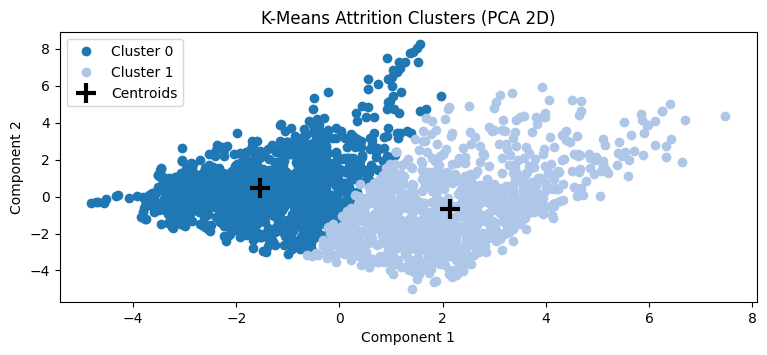

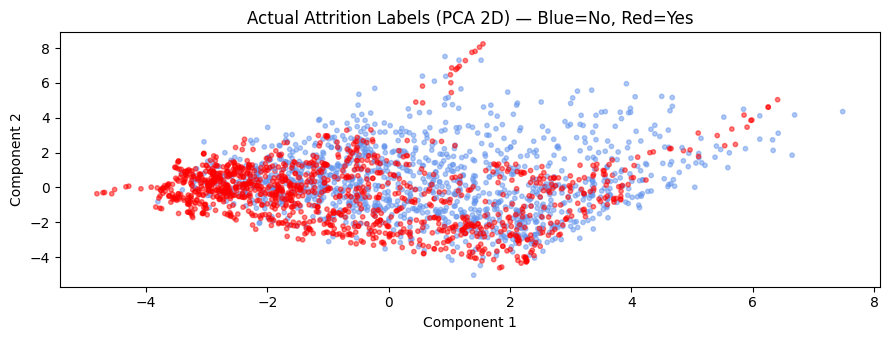


PCA explained variance: 25.5%


In [13]:
# Visualize clusters using PCA (reduce to 2D for plotting)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
centroids_2d = pca.transform(centroids)

# Build sorted_x in 2D for plotting
sorted_x_2d = [X_2d[labels == k] for k in range(2)]
showplotwithclass_2d(sorted_x_2d, centroids_2d, title="K-Means Attrition Clusters (PCA 2D)")

# Also show actual attrition labels for comparison
plt.figure(figsize=(9, 3.5))
colors_actual = ['cornflowerblue' if y == 0 else 'red' for y in attrition_binary]
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors_actual, alpha=0.5, s=10)
plt.xlabel("Component 1", fontsize=10)
plt.ylabel("Component 2", fontsize=10)
plt.title("Actual Attrition Labels (PCA 2D) — Blue=No, Red=Yes", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [14]:
# Compare with sklearn KMeans as baseline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sklearn_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
sklearn_labels = sklearn_kmeans.fit_predict(X)
sklearn_pred, sklearn_acc = map_clusters_to_labels(sklearn_labels, attrition_binary)

tp_sk = np.sum((sklearn_pred == 1) & (attrition_binary == 1))
fp_sk = np.sum((sklearn_pred == 1) & (attrition_binary == 0))
fn_sk = np.sum((sklearn_pred == 0) & (attrition_binary == 1))
prec_sk = tp_sk / (tp_sk + fp_sk) if (tp_sk + fp_sk) > 0 else 0
rec_sk = tp_sk / (tp_sk + fn_sk) if (tp_sk + fn_sk) > 0 else 0
f1_sk = 2 * prec_sk * rec_sk / (prec_sk + rec_sk) if (prec_sk + rec_sk) > 0 else 0

print("=" * 50)
print("  Comparison: From-Scratch vs Sklearn (K=2)")
print("=" * 50)
print(f"  {'Metric':<12} {'From-Scratch':<15} {'Sklearn':<15}")
print(f"  {'-'*42}")
print(f"  {'Accuracy':<12} {accuracy:<15.4f} {sklearn_acc:<15.4f}")
print(f"  {'Precision':<12} {precision:<15.4f} {prec_sk:<15.4f}")
print(f"  {'Recall':<12} {recall:<15.4f} {rec_sk:<15.4f}")
print(f"  {'F1-Score':<12} {f1:<15.4f} {f1_sk:<15.4f}")
print(f"  {'Inertia':<12} {inertia:<15.2f} {sklearn_kmeans.inertia_:<15.2f}")

  Comparison: From-Scratch vs Sklearn (K=2)
  Metric       From-Scratch    Sklearn        
  ------------------------------------------
  Accuracy     0.5946          0.5970         
  Precision    0.5813          0.5845         
  Recall       0.6761          0.6713         
  F1-Score     0.6251          0.6249         
  Inertia      72897.59        72897.29       
